In [ ]:
# Our user defined plotting functions are in the utils folder. Please navigate there to use.
include(joinpath(@__DIR__, "..", "..", "..", "utils", "plot_utils.jl"))

Welcome to the "how to" of Markov Chain Monte Carlo using Turing. A Julia software package allowing you to fit complex models with ease. 

## Case Study 2: Logistic Growth

We are going to establish a logistic model in this case study. The ODE and it's solution will be defined in the near future.  

First things first. Data! You want to read your data into a DataFrame. It's also smart to handle any necessary data conversions during this step. You may not need to and that's just fine! It all depends on what you are looking for.

Note: The "+ 1e-9" is merely a fail-safe against divide-by-zero errors when doing a log transform. Adding a value infitesimally near 0 makes no impact on the data itself and prevents the aformentioned error. Good quick trick to know!

In [ ]:
## Cell 1 ## 

using CSV, DataFrames

# from your data-prep cell
df = CSV.read("../../../case_study_2/python/data/total_cells.csv", DataFrame)

times    = df[end-14:end, :1]
y_obs    = df[end-14:end, :2] * 1e6
log_y_obs = log.(y_obs .+ 1e-9)

First we will setup the logistic ODE that will adapt to the data. To do this, you will use variables that Turing gives you by 'default'. Let me explain. Notice the 4 parameters being passed in. **du**, **u**, **p**, and **t**. **du** is to hold your ODE system. **u** are you starting states. **p** are your parameters. **t** are your times. Turing and Julia will handle the passing of these under the hood. Just make sure you declare them correctly and in proper order. If you have states 1 and 2 then EVERYWHERE you make sure those states are passed in that exact order. Same with your parameters. Lots of things happen under the hood here for you and things are not always 'explicitly' passed, so make sure when you do pass things your order is always preserved. 

**P**: Initial Value  
**r**: Growith Rate  
**K**: Carrying Capacity

$$
\frac{dP}{dt} = r \left(1 - \frac{P}{K}\right) P
$$

In [ ]:
## Cell 2 ##

function ode(du, u, p, t)
    P = u
    r, K = p

    du[1] = r * (1 - P / K) * P

    return nothing
end

This is where we create the MCMC 'loop': Sample Priors -> Estimate ODE @ times -> check fit

We declare the function to be probabilistic model named **fit_ode** using the **@model** tag. The inputs are as follows.

**log_y_obs**: Our log transformed observed data.  
**times**: The times at which the ODE is evaluated.  
**prob**: The prebuilt ODE.  

Next, priors. You have all kinds of options. Uniform, normal, lognormal, halfnormal. It all depends on what you need. With these uniform priors we are essentially saying. We believe the proper value for the model will be equally likely within this range and WILL NOT be outside it. Your half normal distribution is a PDF that is only positive and extends to infinity. This is usually used for your error or standard deviation since neither can be negative and you can tune how quickly it tails off. Below are the priors visualized.

<img src="../../figures/priors_c2p1.png" width="300"/>

Next is solving the ODE. This will be a 2 step process. 

**1**: remake your problem with newly sampled elements.  
The inputs are as follows:  
**prob**: Premade ODE system.  
**u0**: State priors.  
**p**: Parameter priors.  
**tspan**: first and last of your observed times.   


**2**: solve the system at specific time points.  
the inputs are as follows:  
**pr**: remade system  
**Tsit5()**: Default.  
**saveat**: observed times.  
**abstol / restol**: Absolute tolerance / Relative tolerance. Default value chosen.   

**note**: See how when you're passing in values to this julia function there are both **,** and **;**? In julia this is to mark the difference between positional arguments (before **;**) and keyword arguments (after **;**).

The final part of the model is getting the likelihood (or fit if you prefer) of the model to the observed data. It's a bit layered here so we'll break it down part by part.

**log.(Array(sol)[1, :] .+ 1e-9)**: **sol** is the solver output. We force it into an array and grab the first row using the **[1, :]** indexing. Remember to be intentional with your indexing. Finally, we log scale the prediction.  
**log_y_obs ~ arraydist(Normal.(log_y_pred, sigma))**: This is the actual likelihood calculation. Ensure the variable preceding the **~** here is the same as the one passed into **fit_ode**.


In [ ]:
## Cell 3 ##

using Turing
@model function fit_ode(log_y_obs, times, prob)
    r ~ Uniform(0.5, 1.0)
    K ~ Uniform(1e6, 4e7)

    P0 ~ Uniform(1e5, 3e5)
    
    sigma ~ truncated(Normal(0, 3), 0, Inf)

    pr = remake(prob;
                p = [r, K],
                u0 = [P0],
                tspan = (times[1], times[end]))

    sol = solve(pr, Tsit5();
                abstol = 1e-6, reltol = 1e-6,
                saveat = times)

    log_y_pred = log.(Array(sol)[1, :] .+ 1e-9)
    log_y_obs ~ arraydist(Normal.(log_y_pred, sigma))
end

This block is where we declare the ODE with some starter values, call the model, and run the sampling.

To start,

**u0**: Initial state value(s). Make the inital value(s) from the observed data.  
**p**: Initial parameter value(s). Make these a value in the specified range of the prior you declared. Here we chose the low end of the uniform distribution.  
**tspan**:  first and last values from your observed times.  
**prob**: The prebuild ODE.

Next is the call to run the sampling. 

**model**: The model created above.  
**NUTS(1000, .95)**: This is telling you to use the NUTS sampler. 1000 is the amount of 'warm up' iterations it will do under the hood. .95 is the acceptance rate of the 'improved' solutions.   
**MCMCSerial()**: Tells the solver to run the chains sequentially.   
**1000**: number of posterior samples to be generated.  
**3**: number of chains.  
**progress**: either hides or shows the progress bar. Up to you.

In [ ]:
## Cell 4 ##

using DifferentialEquations

u0 = [y_obs[1]]
p = [0.5, 1e6]
tspan = (times[1], times[end])
prob = ODEProblem(ode, u0, tspan, p)

model    = fit_ode(log_y_obs, times, prob)
chain    = sample(model, NUTS(1000, .95), MCMCSerial(), 1000, 4; progress=false)

┌ Info: Found initial step size
│   ϵ = 0.05
└ @ Turing.Inference C:\Users\Whisk\.julia\packages\Turing\Avpxw\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.4
└ @ Turing.Inference C:\Users\Whisk\.julia\packages\Turing\Avpxw\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.4
└ @ Turing.Inference C:\Users\Whisk\.julia\packages\Turing\Avpxw\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.20078125000000002
└ @ Turing.Inference C:\Users\Whisk\.julia\packages\Turing\Avpxw\src\mcmc\hmc.jl:215


To interpret the output we have some user-defined postprocessing and plotting functions. They are in our GitHub repo.

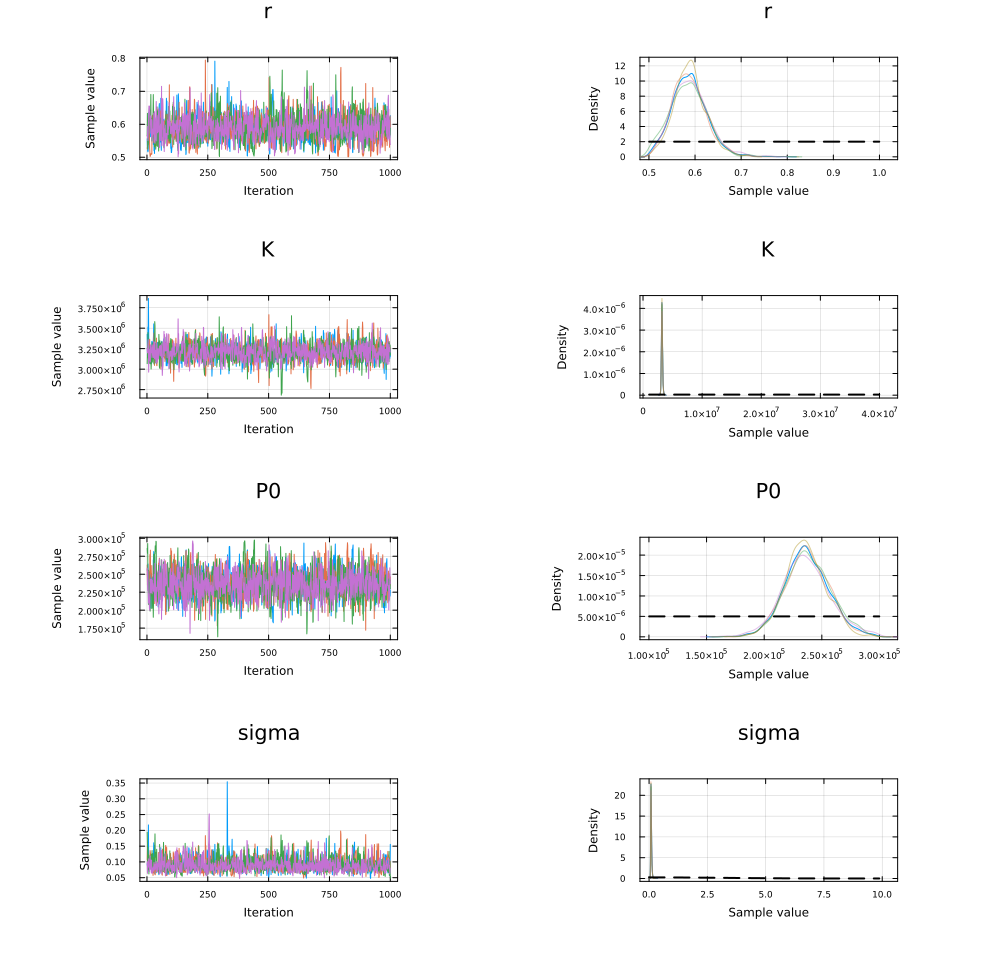

In [6]:
priors = Dict{Symbol,Distribution}(
    :r     => Uniform(0.5, 1.0),
    :K     => Uniform(1e6, 4e7),
    :P0    => Uniform(1e5, 3e5),
    :sigma => truncated(Normal(0, 3), 0, Inf),
)

order = [:r, :K, :P0, :sigma]
plot_trace_with_priors(chain; priors=priors, var_order=order, per_chain_density=true)  # also per-chain densities

Now we interpret the results. Remember the ODE's from before.

$$
\frac{dP}{dt} = r \left(1 - \frac{P}{K}\right) P
$$

Take note of x-axis values at the peaks of the PDFs and the variables they represent. The x-axis values at those peaks are what the model found to be the optimal value for the equation. The right hand column is a frequency plot. This is just to make sure the model is exploring the parameter space well enough. 


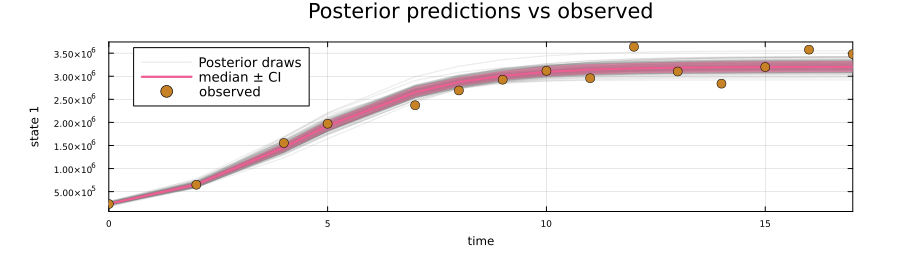

In [7]:
init_syms = [:P0]
param_syms = [:r, :K]
t_obs = times
y_obs = y_obs

plt = overlay_posterior_on_observed(
    chain, ode, t_obs, y_obs;
    init_syms=init_syms,
    param_syms=param_syms,
    which_states=[1],     # choose states to plot
    n_draws=150,            # how many posterior paths to overlay
    plot_ribbon=true,       # median ± CI band
    legend=:topleft,
    ribbon_q=(0.1, 0.9),    # CI limits
    logy=false
)
display(plt)


This plot is showing how well the range of estimated chains fit the observed data.

**CONGRATULATIONS!** you just ran you first MCMC!

## Case Study 2: Logistic Growth and Death

Now on to a more complex model. We will be using the same data as before as well as some data on dead cells. We will also being using two ODEs!

In [ ]:
## Cell 5 ##

using CSV, DataFrames

cells = CSV.read("../../../case_study_2/python/data/total_cells.csv", DataFrame)
death = CSV.read("../../../case_study_2/python/data/death_percentage.csv", DataFrame)

cells_times  = cells[end-14:end, :1]
cells_obs    = cells[end-14:end, :2] * 1e6
log_cells_obs = log.(cells_obs .+ 1e-9)

death_times = death[end-14:end, :1]
death_obs   = death[end-14:end, :2] .* (cells_obs ./ 100)
log_death_obs = log.(death_obs .+ 1e-9)

**ODE for living cells accounting for cell death**

$$
\frac{dP}{dt} = r \left(1 - \frac{P}{K}\right) P - \delta P
$$

**ODE for dead cells**

$$
\frac{dD}{dt} = \delta P
$$

We follow the same rules as before when creating this ODE. It's very easy to create more complex models with multiple equations. Remember your odering! Equations should be in the same order as the states they correspond to. BE CAREFUL WITH THE ORDER OF EVERYTHING. IT ALL MATTERS.

In [ ]:
## Cell 6 ##

function ode(du, u, p, t)
    P, D = u
    r, K, delta = p

    du[1] = r * (1 - P / K) * P - delta * P
    du[2] = delta * P

    return nothing
end

Here is the model. Everything here should make sense. If something is confusing see the explanation above cell 4. Still note that we have two likelihoods at the bottom since we are estimating two states. 

In [ ]:
## Cell 7 ##

using Turing

@model function fit_ode(log_cells_obs, log_death_obs, times, prob)
    r ~ Uniform(0.5, 1.0)
    K ~ Uniform(1e6, 4e7)
    delta ~ Uniform(0.0, 0.15)

    P0 ~ Uniform(1e5, 3e5)
    D0 ~ Uniform(1e4, 7e4)

    sigma_live ~ truncated(Normal(0, 3), 0, Inf)
    sigma_dead ~ truncated(Normal(0, 3), 0, Inf)

    pr = remake(prob;
                p = [r, K, delta],
                u0 = [P0, D0],
                tspan = (times[1], times[end]))
    
    # solve exactly at data times
    sol = solve(pr, Tsit5();
                abstol = 1e-6, reltol = 1e-6,
                saveat = times)
    S = Array(sol) 

    log_cells_pred = log.((S[1, :] + S[2, :]) .+ 1e-9)
    log_death_pred = log.(S[2, :] .+ 1e-9)

    log_cells_obs ~ arraydist(Normal.(log_cells_pred, sigma_live))
    log_death_obs ~ arraydist(Normal.(log_death_pred, sigma_dead))

end

Everything here is that same as before! See the explanation above cell 5 if you forgot something.

In [14]:
## Cell 8 ##

using DifferentialEquations

u0 = [log_cells_obs[1], log_death_obs[1]]
p = [0.5, 1e6, 0.0] 
tspan = (cells_times[1], cells_times[end])
prob = ODEProblem(ode, u0, tspan, p)

model    = fit_ode(log_cells_obs, log_death_obs, cells_times, prob)
chain    = sample(model, NUTS(1000, .95), MCMCSerial(), 1000, 4; progress=false)
 

┌ Info: Found initial step size
│   ϵ = 0.025
└ @ Turing.Inference C:\Users\Whisk\.julia\packages\Turing\Avpxw\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.05
└ @ Turing.Inference C:\Users\Whisk\.julia\packages\Turing\Avpxw\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.2
└ @ Turing.Inference C:\Users\Whisk\.julia\packages\Turing\Avpxw\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.2
└ @ Turing.Inference C:\Users\Whisk\.julia\packages\Turing\Avpxw\src\mcmc\hmc.jl:215


Chains MCMC chain (1000×21×4 Array{Float64, 3}):

Iterations        = 1001:1:2000
Number of chains  = 4
Samples per chain = 1000
Wall duration     = 4.36 seconds
Compute duration  = 4.3 seconds
parameters        = r, K, delta, P0, D0, sigma_live, sigma_dead
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, lp, logprior, loglikelihood

Use `describe(chains)` for summary statistics and quantiles.


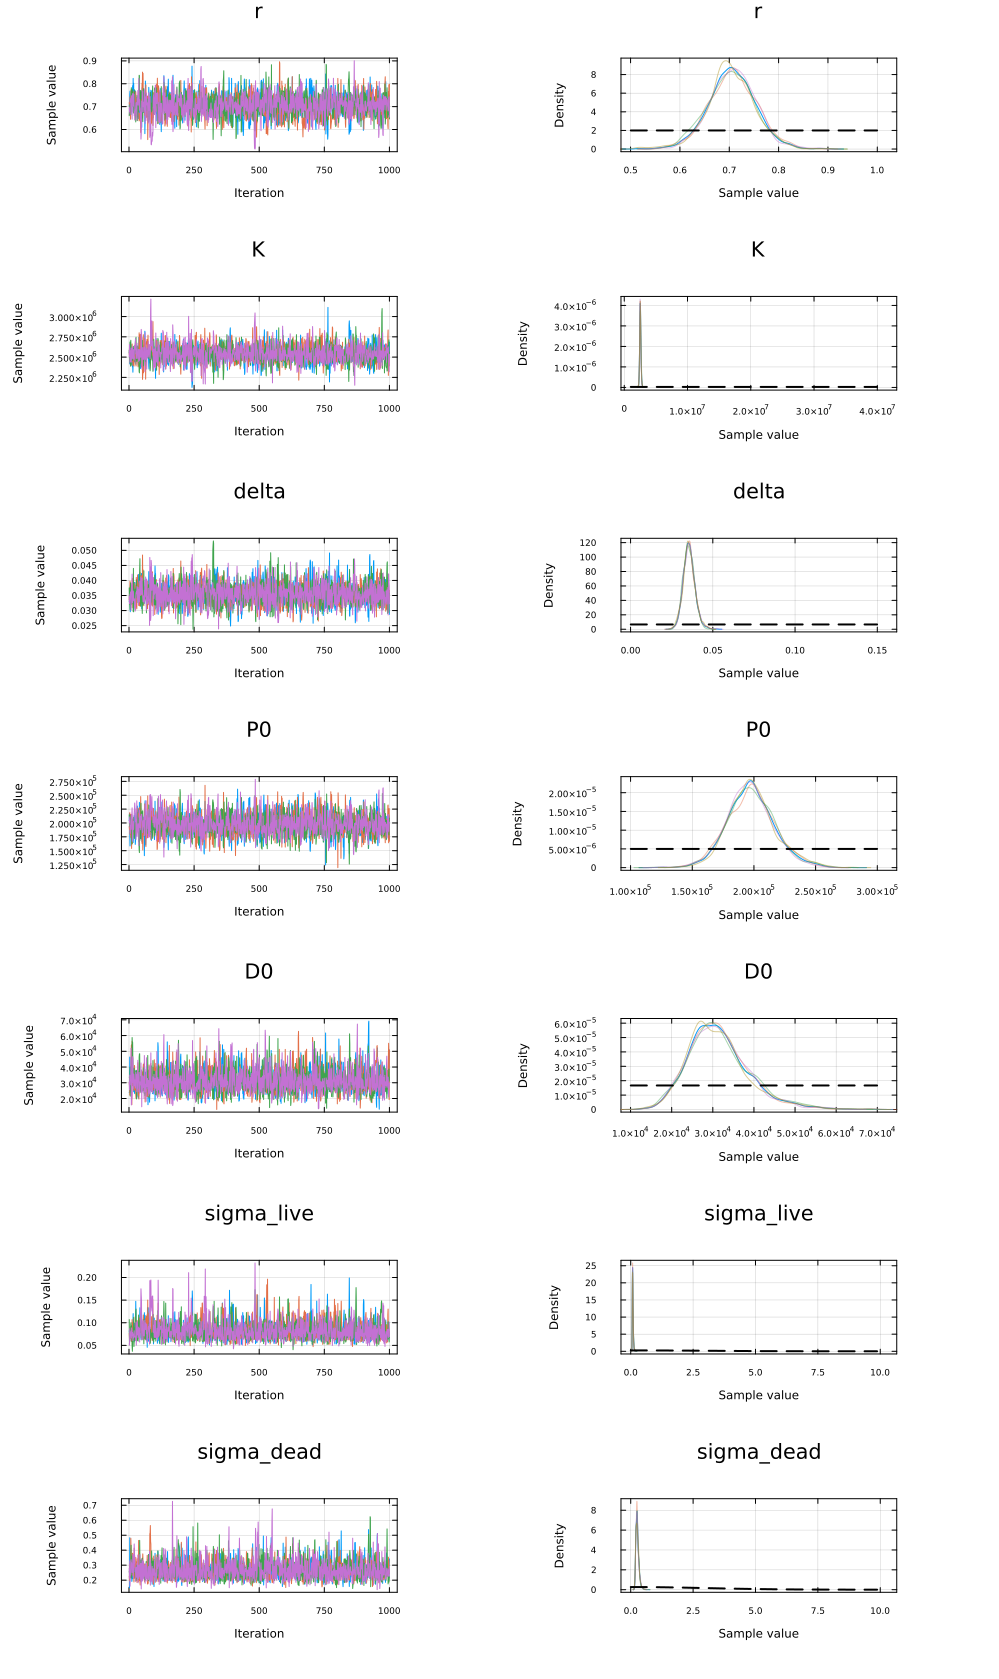

In [15]:
priors = Dict{Symbol,Distribution}(
    :r     => Uniform(0.5, 1.0),
    :K     => Uniform(1e6, 4e7),
    :delta => Uniform(0.0, 0.15),
    :P0    => Uniform(1e5, 3e5),
    :D0    => Uniform(1e4, 7e4),
    :sigma_live => truncated(Normal(0, 3), 0, Inf),
    :sigma_dead => truncated(Normal(0, 3), 0, Inf)
)

order = [:r, :K, :delta, :P0, :D0, :sigma_live, :sigma_dead]

plot_trace_with_priors(chain; priors=priors, var_order=order, per_chain_density=true)  # also per-chain densities

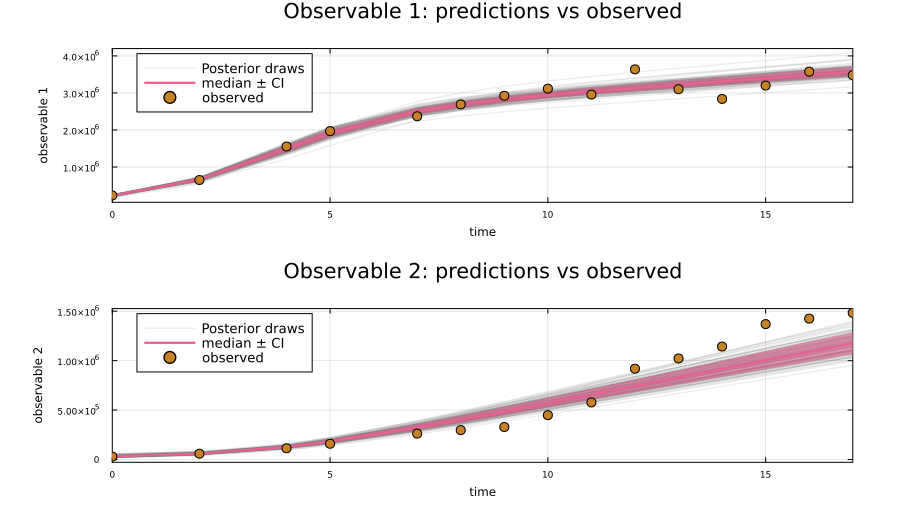

In [16]:
init_syms = [:P0, :D0]
param_syms = [:r, :K, :delta]
t_obs = cells_times
y_obs = hcat(cells_obs, death_obs)

plt = overlay_posterior_on_observed(
    chain, ode, t_obs, y_obs;
    init_syms=init_syms,
    param_syms=param_syms,
    which_states=[1, 2],     # choose states to plot
    pred_transforms=[u -> u[1] + u[2], u -> u[2]], # column1=total(P+D), column2=dead(D)
    legend=:topleft,
    n_draws=150,            # how many posterior paths to overlay
    plot_ribbon=true,       # median ± CI band
    ribbon_q=(0.1, 0.9),    # CI limits
    logy=false
)
display(plt)